# 03 — Preprocesamiento

Define y valida la cadena de preprocesamiento que se aplica a cada imagen
antes de extraer características.

**Cadena:**
```
imagen original → escala de grises → resize 256×256 → Bilateral Filter → CLAHE
```

El preprocesamiento se aplica antes de cualquier cálculo de métricas porque las
imágenes crudas contienen variaciones de brillo y contraste causadas por el equipo
de rayos X, no por el tejido. Después del preprocesamiento, lo que se mide
refleja información clínica real.

In [1]:
import os
import random
import warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
random.seed(42)

In [2]:
DATA_ROOT  = os.path.join(os.path.expanduser('~'), '.cache', 'kagglehub',
                          'datasets', 'usmanshams', 'tbx-11', 'versions', '1', 'TBX11K')
IMG_SIZE   = (256, 256)
LABEL_MAP  = {'health': 0, 'sick': 1, 'tb': 2}
VALID_EXTS = ('.png', '.jpg', '.jpeg')

records = []
imgs_dir = Path(DATA_ROOT) / 'imgs'
for class_name, label in LABEL_MAP.items():
    class_dir = imgs_dir / class_name
    if not class_dir.is_dir():
        continue
    for f in class_dir.iterdir():
        if f.suffix.lower() in VALID_EXTS:
            records.append({'image_path': str(f), 'class_name': class_name, 'label': label})

df_base = pd.DataFrame(records)
print(f'Imágenes cargadas: {len(df_base)}')

Imágenes cargadas: 8400


---
## 1. Función de preprocesamiento

In [3]:
def preprocess(path: str) -> np.ndarray | None:
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)
    img = cv2.bilateralFilter(img, d=9, sigmaColor=80, sigmaSpace=80)
    clahe = cv2.createCLAHE(clipLimit=40, tileGridSize=(8, 8))
    return clahe.apply(img)

---
## 2. Comparativa visual: original vs cada paso

Se muestra el efecto de cada paso del preprocesamiento sobre una imagen de cada clase.

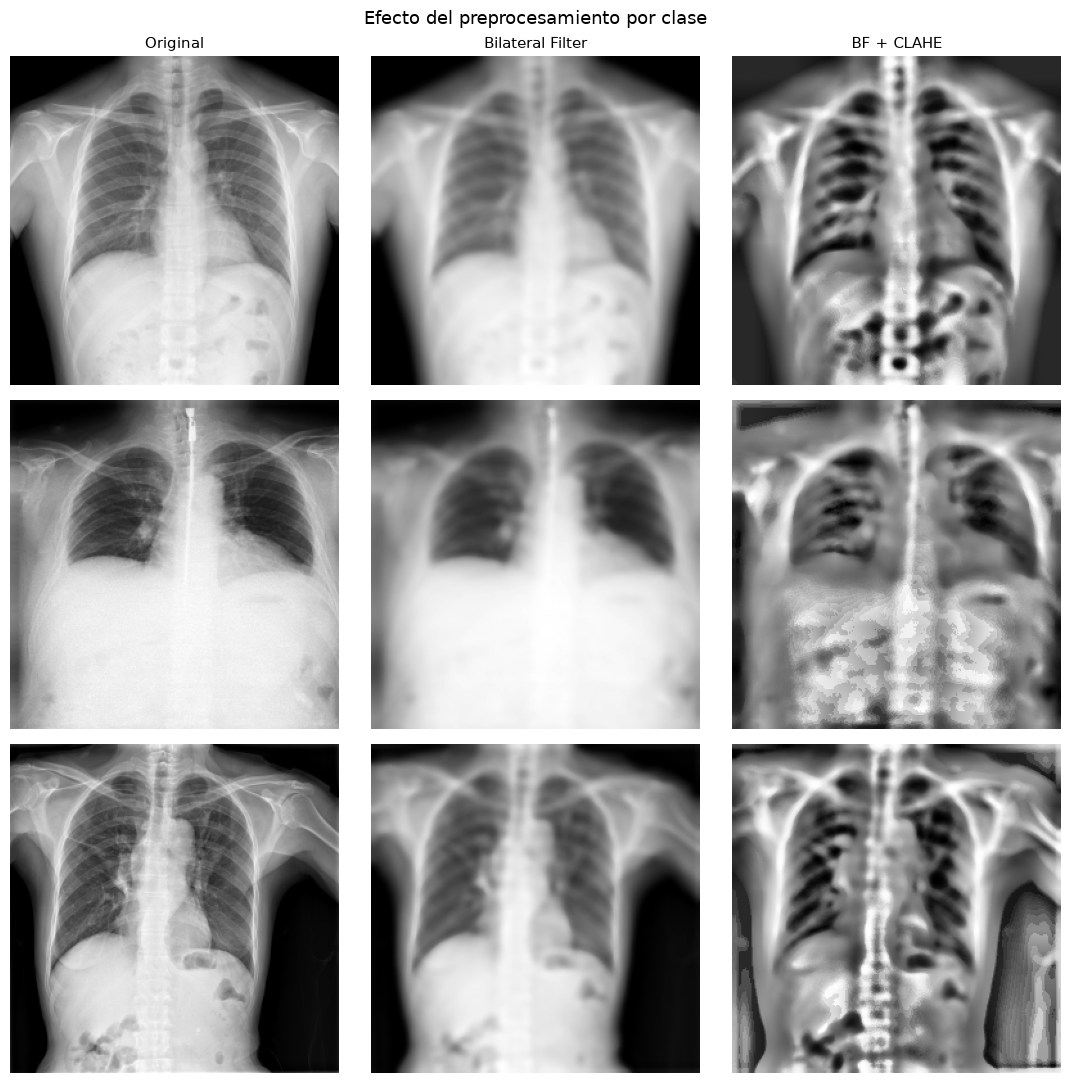

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(11, 11))
titulos = ['Original', 'Bilateral Filter', 'BF + CLAHE']

for row, class_name in enumerate(['health', 'sick', 'tb']):
    path = df_base[df_base['class_name'] == class_name].iloc[0]['image_path']

    original  = cv2.resize(cv2.imread(path, cv2.IMREAD_GRAYSCALE), IMG_SIZE)
    con_bf    = cv2.bilateralFilter(original, d=9, sigmaColor=80, sigmaSpace=80)
    con_clahe = cv2.createCLAHE(clipLimit=40, tileGridSize=(8, 8)).apply(con_bf)

    for col, img in enumerate([original, con_bf, con_clahe]):
        axes[row][col].imshow(img, cmap='gray')
        axes[row][col].axis('off')
        if row == 0:
            axes[row][col].set_title(titulos[col], fontsize=11)
        if col == 0:
            axes[row][col].set_ylabel(class_name, fontsize=11, fontweight='bold')

plt.suptitle('Efecto del preprocesamiento por clase', fontsize=13)
plt.tight_layout()
plt.show()

---
## 3. Efecto en el histograma

El CLAHE redistribuye la intensidad para aprovechar mejor el rango dinámico.
Se comparan los histogramas antes y después sobre una imagen de `tb`.

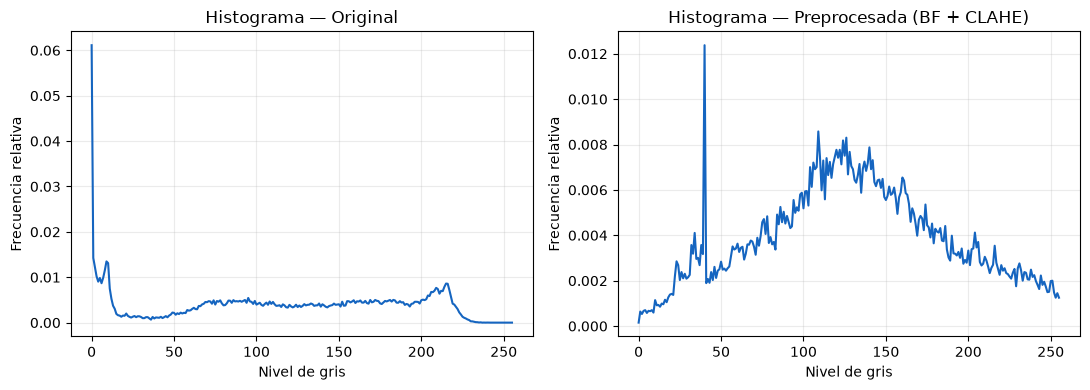

In [5]:
path_tb   = df_base[df_base['class_name'] == 'tb'].iloc[0]['image_path']
original  = cv2.resize(cv2.imread(path_tb, cv2.IMREAD_GRAYSCALE), IMG_SIZE)
procesada = preprocess(path_tb)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, img, titulo in zip(axes, [original, procesada], ['Original', 'Preprocesada (BF + CLAHE)']):
    h = cv2.calcHist([img], [0], None, [256], [0, 256]).flatten()
    ax.plot(h / h.sum(), color='#1565C0', linewidth=1.5)
    ax.set_title(f'Histograma — {titulo}')
    ax.set_xlabel('Nivel de gris')
    ax.set_ylabel('Frecuencia relativa')
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

---
## 4. Histogramas de intensidad por clase — imágenes preprocesadas

El mismo análisis del notebook 02 pero ahora sobre imágenes preprocesadas.
La comparación muestra si el preprocesamiento acentúa o reduce las diferencias
entre clases.

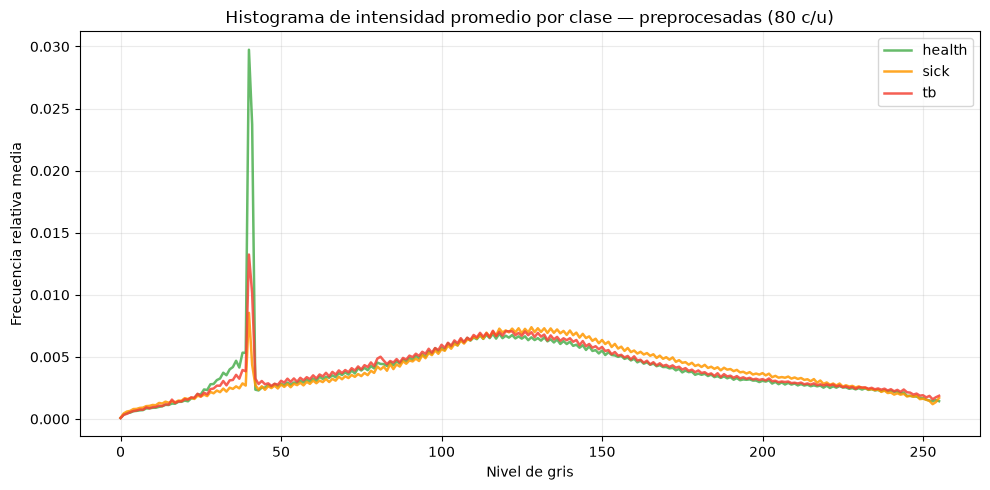

In [6]:
N_HIST = 80
PALETTE = {'health': '#4CAF50', 'sick': '#FF9800', 'tb': '#F44336'}

plt.figure(figsize=(10, 5))

for class_name, color in PALETTE.items():
    muestras  = df_base[df_base['class_name'] == class_name].sample(N_HIST, random_state=42)
    hist_acum = np.zeros(256)
    for _, row in muestras.iterrows():
        img = preprocess(row['image_path'])
        if img is None:
            continue
        h = cv2.calcHist([img], [0], None, [256], [0, 256]).flatten()
        hist_acum += h / h.sum()
    hist_acum /= N_HIST
    plt.plot(hist_acum, color=color, label=class_name, linewidth=1.8, alpha=0.85)

plt.title(f'Histograma de intensidad promedio por clase — preprocesadas ({N_HIST} c/u)')
plt.xlabel('Nivel de gris')
plt.ylabel('Frecuencia relativa media')
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()